<a href="https://colab.research.google.com/github/saptarshi0831/health-risk-app/blob/main/Health_risk_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rishisapt","key":"ea7360a1714d98a944996a98512c6111"}'}

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)

In [ ]:
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d nasirayub2/human-vital-sign-dataset
!unzip human-vital-sign-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/nasirayub2/human-vital-sign-dataset
License(s): CC0-1.0
100% 14.0M/14.0M [00:02<00:00, 6.25MB/s]

Archive:  human-vital-sign-dataset.zip
  inflating: human_vital_signs_dataset_2024.csv  


In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Dataset
data = pd.read_csv('human_vital_signs_dataset_2024.csv')
data.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


EDA

In [ ]:
print("Shape:", data.shape)

Shape: (200020, 17)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient ID                200020 non-null  int64  
 1   Heart Rate                200020 non-null  int64  
 2   Respiratory Rate          200020 non-null  int64  
 3   Timestamp                 200020 non-null  object 
 4   Body Temperature          200020 non-null  float64
 5   Oxygen Saturation         200020 non-null  float64
 6   Systolic Blood Pressure   200020 non-null  int64  
 7   Diastolic Blood Pressure  200020 non-null  int64  
 8   Age                       200020 non-null  int64  
 9   Gender                    200020 non-null  object 
 10  Weight (kg)               200020 non-null  float64
 11  Height (m)                200020 non-null  float64
 12  Derived_HRV               200020 non-null  float64
 13  Derived_Pulse_Pressure    200020 non-null  i

In [ ]:
print(data.isnull().sum())

Patient ID                  0
Heart Rate                  0
Respiratory Rate            0
Timestamp                   0
Body Temperature            0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Age                         0
Gender                      0
Weight (kg)                 0
Height (m)                  0
Derived_HRV                 0
Derived_Pulse_Pressure      0
Derived_BMI                 0
Derived_MAP                 0
Risk Category               0
dtype: int64


In [ ]:
data.describe()

,Patient ID,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
count,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000
mean,100010.500000,79.533747,15.489451,36.748353,97.504372,124.437971,79.499625,53.446275,74.996419,1.750031,0.099970,44.938346,25.003625,94.479074
std,57740.944759,11.552894,2.294472,0.433290,1.442598,8.656946,5.757248,20.786802,14.471502,0.144554,0.028861,10.404945,6.447143,4.797891
min,1.000000,60.000000,12.000000,36.000004,95.000007,110.000000,70.000000,18.000000,50.000156,1.500001,0.050000,21.000000,12.505974,83.333333
25%,50005.750000,70.000000,13.000000,36.372613,96.256859,117.000000,75.000000,35.000000,62.423615,1.624777,0.074955,37.000000,20.134367,91.000000
50%,100010.500000,80.000000,15.000000,36.747741,97.509629,124.000000,79.000000,53.000000,74.977169,1.750478,0.099988,45.000000,24.320776,94.333333
75%,150015.250000,90.000000,17.000000,37.123003,98.755722,132.000000,84.000000,71.000000,87.539510,1.875310,0.124917,53.000000,29.187169,98.000000
max,200020.000000,99.000000,19.000000,37.499992,99.999963,139.000000,89.000000,89.000000,99.999765,1.999997,0.149999,69.000000,44.376487,105.666667


Data Cleaning

In [40]:
data.columns

Index(['Heart Rate', 'Respiratory Rate', 'Body Temperature',
       'Oxygen Saturation', 'Systolic Blood Pressure',
       'Diastolic Blood Pressure', 'Age', 'Gender', 'Weight (kg)',
       'Height (m)', 'Derived_HRV', 'Derived_Pulse_Pressure', 'Derived_BMI',
       'Derived_MAP', 'Risk Category'],
      dtype='object')

In [ ]:
# drop columns
data = data.drop(columns=['Patient ID', 'Timestamp'])

# Mapping
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})

Visualization (EDA)

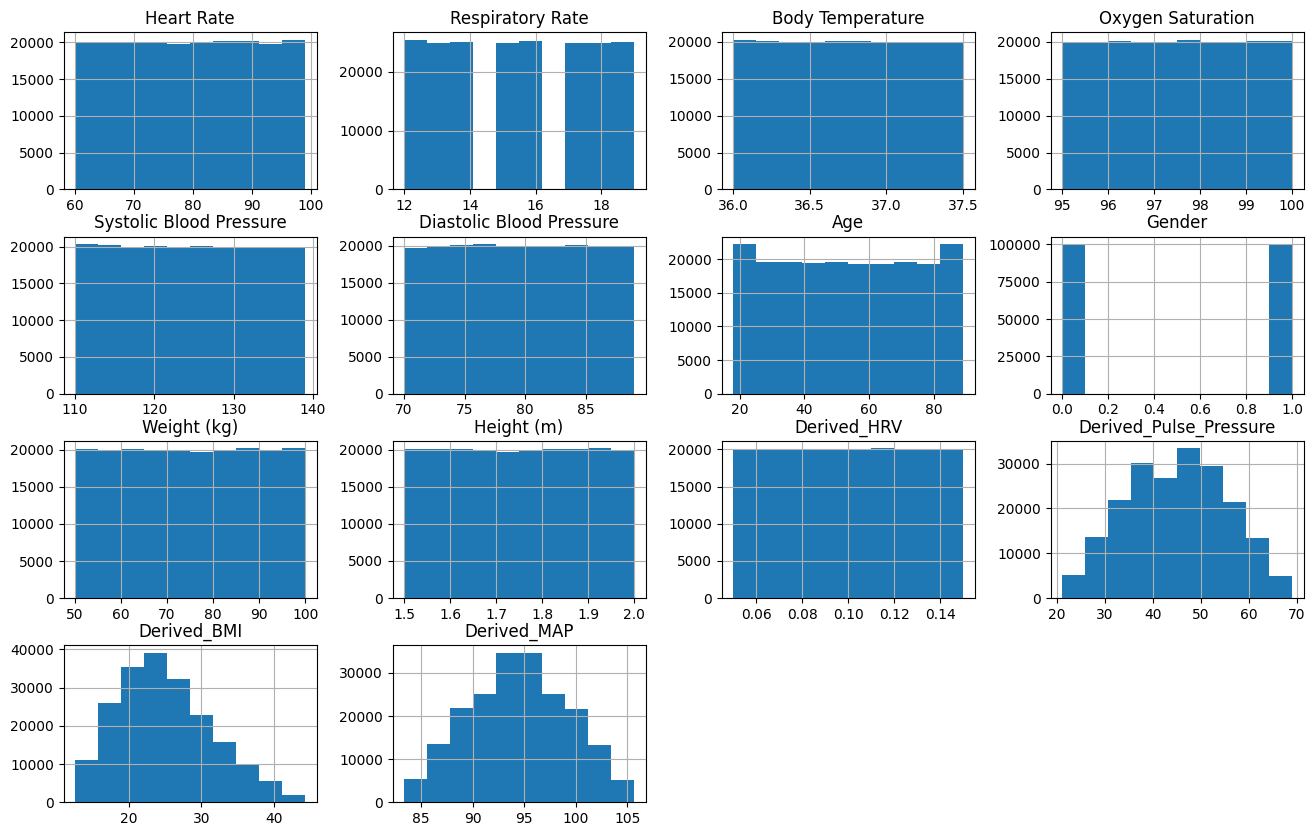

In [ ]:
data.hist(figsize=(16,10))
plt.show()

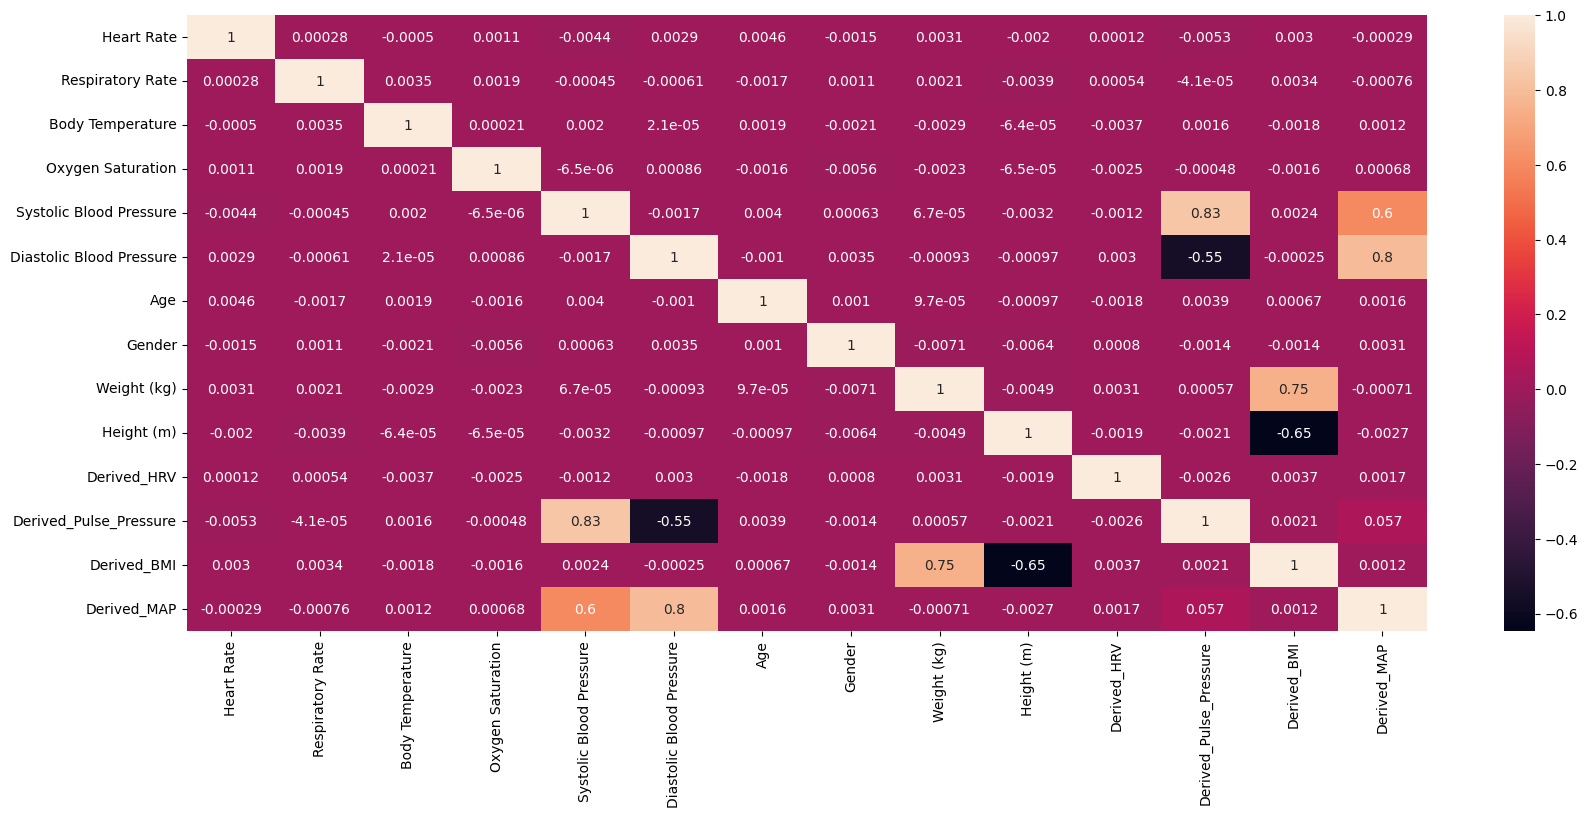

In [39]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20,8))
sns.heatmap(numeric_data.corr(), annot=True)
plt.show()

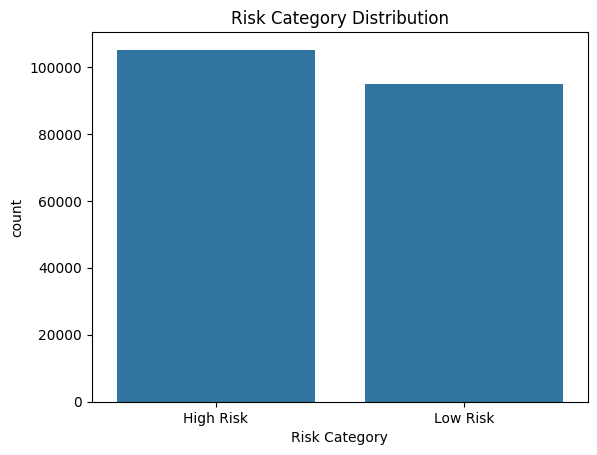

In [ ]:
sns.countplot(x='Risk Category', data=data)
plt.title("Risk Category Distribution")
plt.show()

Feature Selection

In [ ]:
X = data.drop(columns=[
    'Risk Category',
    'Derived_BMI',
    'Derived_MAP',
    'Derived_Pulse_Pressure',
    'Derived_HRV'
])

y = data['Risk Category']

In [ ]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Model train
model = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10)

In [ ]:
# model evaluation
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9155334466553344
Test Accuracy: 0.9134336566343366


In [ ]:
# accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9134336566343366


In [44]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

   High Risk       0.97      0.86      0.91     20949
    Low Risk       0.86      0.97      0.91     19055

    accuracy                           0.91     40004
   macro avg       0.92      0.92      0.91     40004
weighted avg       0.92      0.91      0.91     40004



In [ ]:
# model prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9134336566343366
              precision    recall  f1-score   support

   High Risk       0.97      0.86      0.91     20949
    Low Risk       0.86      0.97      0.91     19055

    accuracy                           0.91     40004
   macro avg       0.92      0.92      0.91     40004
weighted avg       0.92      0.91      0.91     40004



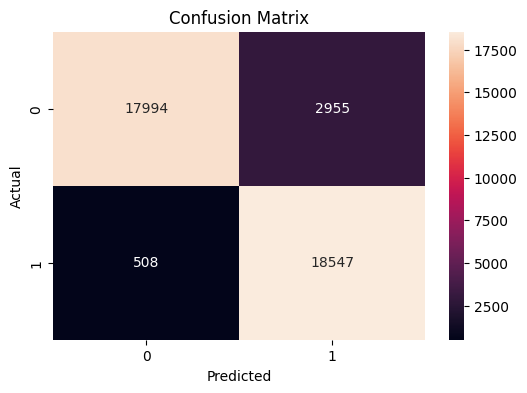

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

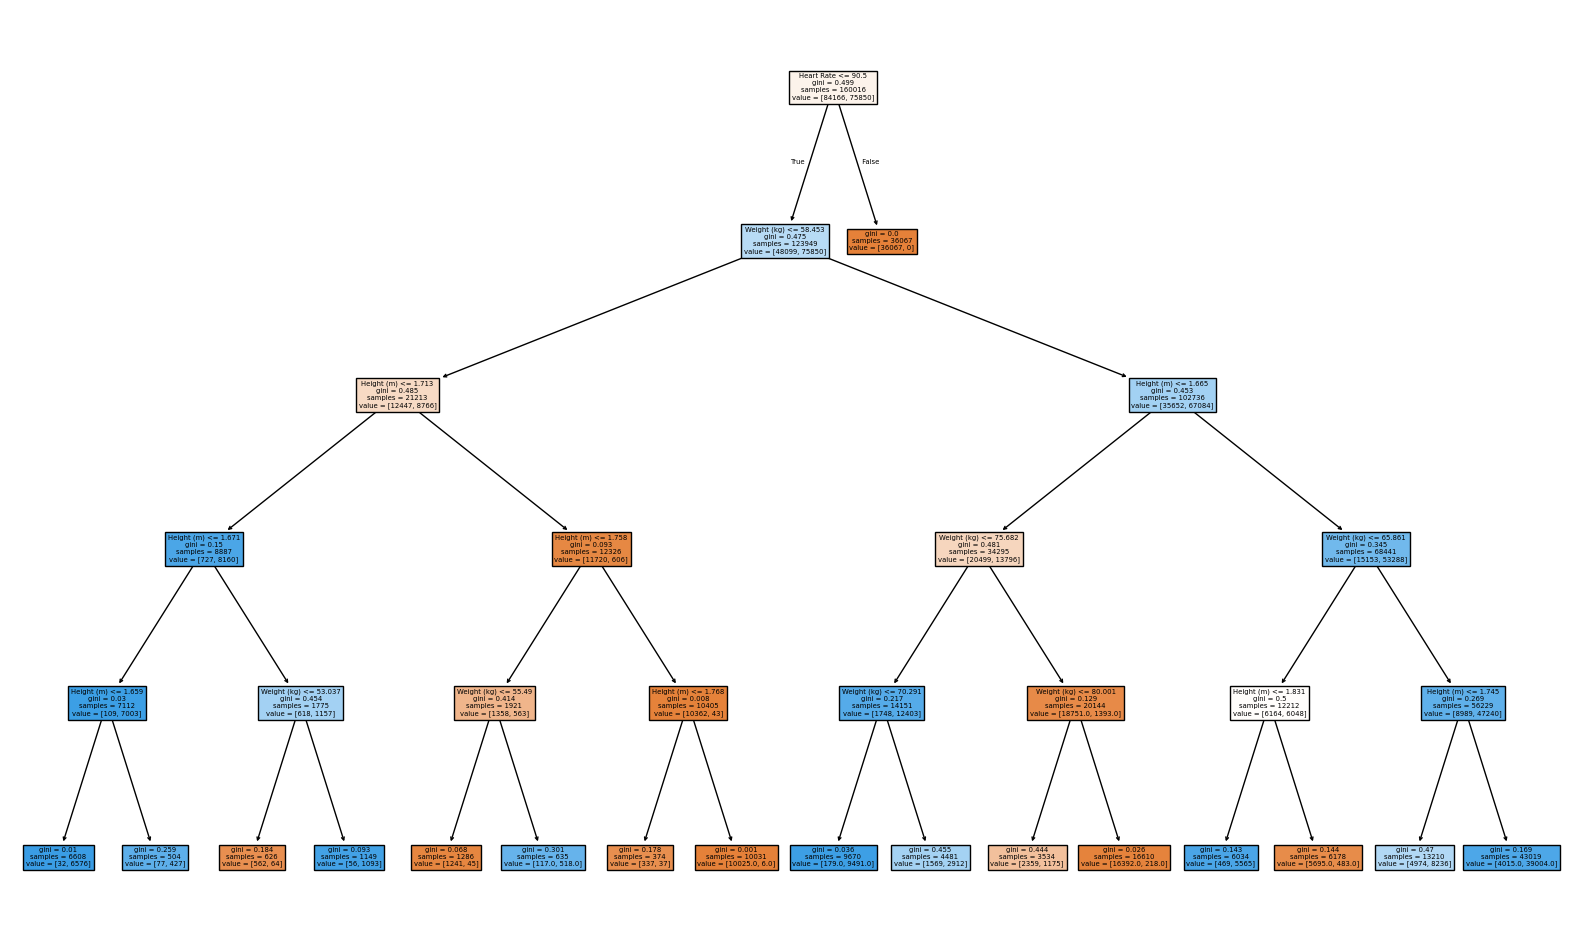

In [43]:
# Decision Tree Plot
plt.figure(figsize=(20,12))
plot_tree(model, feature_names=X.columns, filled=True)
plt.show()

In [ ]:
# sample prediction
sample = [X.iloc[3].values]
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: ['High Risk']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
